# WN stim regen demo
Verifying that stim regen gives correct STA
VR 2025-07-08

In [21]:
import retinanalysis as ra
import numpy as np
import matplotlib.pyplot as plt
import tqdm.auto as tqdm

def compute_sta(cell_idx, e_idx, s1: ra.StimBlock, r1: ra.ResponseBlock, n_depth = 15):
    total_sps = r1.df_spike_times.at[cell_idx, 'binned_spikes'][e_idx].sum()
    print(f'Computing STA for cell idx {cell_idx} with total spikes: {total_sps}')
    lags = np.arange(0,n_depth)

    all_frames = s1.stim_data['frames']
    sta = np.zeros((len(lags), all_frames[0].shape[1], all_frames[0].shape[2]))
    pre_bins = r1.bin_rate * s1.df_epochs.at[0, 'epoch_parameters']['preTime'] * 1e-3
    pre_bins = np.round(pre_bins).astype(int)
    
    for i, lag in tqdm.tqdm(list(enumerate(lags)), desc="STA Depth"):
        # Only Red channel for simplicity
        frames = all_frames[0, :,:,:, 0]
        bs = r1.df_spike_times.at[cell_idx, 'binned_spikes'][e_idx, pre_bins:pre_bins + len(frames)]
        if lag > 0:
            bs = bs[lag:]
            frames = frames[:-lag]
        # Keep only timepoints with a spike
        mask = np.where(bs > 0)[0]
        if len(mask) == 0:
            print(f'No spikes found for cell idx {cell_idx} in epoch {e_idx}')
            continue
        bs = bs[mask]
        frames = frames[mask]
        frames = np.moveaxis(frames, 0, -1)
        sta[i] += np.matmul(frames, bs)
    return sta

In [2]:
exp_name = '20251216C'
datafile_name = 'data001'
e_idx = 2
pp = ra.create_mea_pipeline(exp_name, datafile_name)

Initializing StimBlock for 20251216C block 4259
Warning, none of the noise chunks in this experiment have typing files, chunk3 is None

Initializing ResponseBlock for 20251216C block 4259
Loading frame monitor data from /Volumes/data-1/data/h5/20251216C.h5 ...
Loaded (20, 180500) frame_data.

Loading VCD from /Volumes/data-1/data/sorted/20251216C/data001/kilosort2.5 ...
VCD loaded with 598 cells.

Using chunk3 for AnalysisChunk

Loading VCD from /Volumes/data-1/analysis/20251216C/chunk3/kilosort2.5 ...
VCD loaded with 530 cells.

Issue with id 105...
Will remove from cell_ids list.
Issue with id 571...
Will remove from cell_ids list.
Issue with id 607...
Will remove from cell_ids list.
Issue with id 609...
Will remove from cell_ids list.
Issue with id 617...
Will remove from cell_ids list.
Issue with id 618...
Will remove from cell_ids list.
Issue with id 736...
Will remove from cell_ids list.
Issue with id 740...
Will remove from cell_ids list.
Issue with id 749...
Will remove from ce

Let's bin spike times.

In [3]:
pp.response_block.bin_spike_times_by_frames()

Binning spikes for cells:   0%|          | 0/598 [00:00<?, ?it/s]

Mean frame rate: 59.94 Hz



Let's regenerate WN frames for the first epoch

In [4]:
pp.stim_block.regenerate_stimulus(ls_epochs=[e_idx])

Regenerating stimulus for epochs: [2] in block: 4259
Using regeneration function: make_spatial_noise


  0%|          | 0/1 [00:00<?, ?it/s]

numXStixels: 42, numYStixels: 27, numXChecks: 203, numYChecks: 127
chromaticClass: BY, unique_frames: 10789, repeat_frames: 0
stepsPerStixel: 5, seed: 259824372, frameDwell: 1
gaussianFilter: 0, filterSdStixels: 1.0
Grid size: 9 pix, Stixel size: 45 pix
gridValues: (21578, 27, 42)
fullGrid: (21578, 135, 210)
frameValues: (21578, 127, 203)
Precise Crop X: 3.50, Crop Y: 4.00
Rounded Crop X: 4, Crop Y: 4
stimulus: (10789, 127, 203, 3)


100%|██████████| 1/1 [00:23<00:00, 23.37s/it]


Regenerated stimulus with keys: ['frames', 'steps', 'canvas_size']


Let's use the compute_sta function defined up top to calculate and plot the STA for cell 2

In [26]:
cell_idx = 1
sta = compute_sta(cell_idx, e_idx, pp.stim_block, pp.response_block)

Computing STA for cell idx 1 with total spikes: 2812.0


STA Depth:   0%|          | 0/15 [00:00<?, ?it/s]

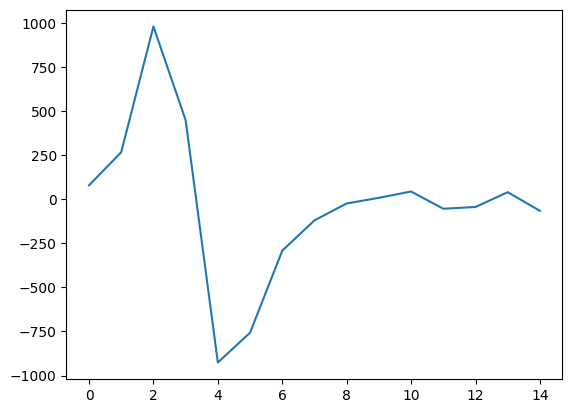

In [27]:
# Get Red channel spatial map, and peak pixel
cell_id = pp.response_block.cell_ids[cell_idx]

sm = pp.analysis_chunk.d_spatial_maps[cell_id][:,:,0]
peak = np.unravel_index(np.argmax(sm), sm.shape)

plt.plot(sta[:,peak[0], peak[1]])

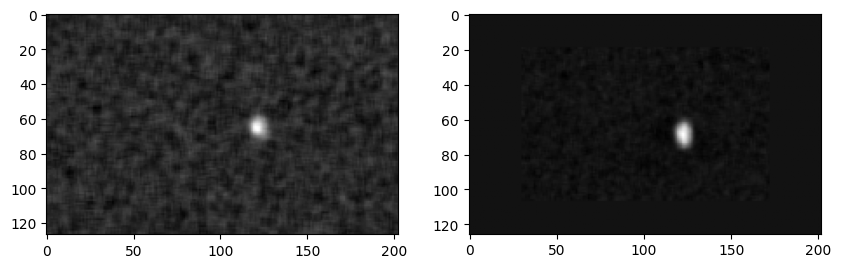

In [33]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(sta[2,:,:], cmap='gray')
plt.subplot(122)
plt.imshow(sm, cmap='gray')